# MNIST Classification with blox

This tutorial demonstrates how to train a Convolutional Neural Network (CNN) on MNIST using **blox**.

We will strictly follow a probabilistic approach:
1.  **Model**: Defines a conditional distribution $P(Y | X)$.
2.  **Objective**: Maximize the likelihood of the data (minimize Negative Log Likelihood).

We use **Distrax** to handle the probability distributions.

In [ ]:
# Install necessary packages.
!pip install -q jax-blox optax tensorflow tensorflow-datasets matplotlib distrax

In [ ]:
import blox as bx
import distrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import tensorflow as tf
import tensorflow_datasets as tfds

# Set random seed for reproducibility.
tf.random.set_seed(0)

In [3]:
batch_size = 32
train_steps = 1200
eval_every = 200


def get_datasets(batch_size: int, train_steps: int):
  """Load MNIST datasets as tf.data Datasets."""

  def normalize(sample):
    image = tf.cast(sample['image'], tf.float32) / 255.0
    return {'image': image, 'label': sample['label']}

  train_ds = tfds.load('mnist', split='train')
  train_ds = train_ds.map(normalize)
  train_ds = train_ds.repeat().shuffle(1024)
  train_ds = train_ds.batch(batch_size, drop_remainder=True)
  train_ds = train_ds.take(train_steps).prefetch(-1)

  test_ds = tfds.load('mnist', split='test')
  test_ds = test_ds.map(normalize)
  test_ds = test_ds.batch(batch_size, drop_remainder=True).prefetch(-1)

  return train_ds, test_ds


train_ds, test_ds = get_datasets(batch_size, train_steps)
sample_batch = next(iter(train_ds.as_numpy_iterator()))
print(f'Batch shape: {sample_batch["image"].shape}')

2025-12-18 03:01:31.070357: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Batch shape: (32, 28, 28, 1)


2025-12-18 03:01:32.118724: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [4]:
class CNN(bx.Module):
  """A probabilistic CNN classifier."""

  def __init__(self, graph: bx.Graph, num_classes: int = 10):
    super().__init__(graph)
    self.conv1 = bx.Conv(
        graph.child('conv1'), output_channels=32, kernel_size=(3, 3)
    )
    self.conv2 = bx.Conv(
        graph.child('conv2'), output_channels=64, kernel_size=(3, 3)
    )
    self.linear1 = bx.Linear(graph.child('linear1'), output_size=256)
    self.linear2 = bx.Linear(graph.child('linear2'), output_size=num_classes)
    self.dropout = bx.Dropout(graph.child('dropout'), rate=0.5)

  def __call__(self, params: bx.Params, x: jax.Array, is_training: bool = True):
    # Convolutional feature extraction.
    x, params = self.conv1(params, x)
    x = jax.nn.relu(x)
    x = bx.avg_pool(x, window_shape=(2, 2), strides=2)

    x, params = self.conv2(params, x)
    x = jax.nn.relu(x)
    x = bx.avg_pool(x, window_shape=(2, 2), strides=2)

    # Flatten and dense layers.
    x = x.reshape((x.shape[0], -1))
    x, params = self.linear1(params, x)
    x = jax.nn.relu(x)
    x, params = self.dropout(params, x, is_training=is_training)

    # Output logits for the Categorical distribution.
    logits, params = self.linear2(params, x)
    return logits, params

In [5]:
# Create model components.
graph = bx.Graph('mnist')
model = CNN(graph.child('cnn'))
rng = bx.Rng(graph.child('rng'), seed=0)

# Initialize params with a sample batch item.
params = bx.Params(rng=rng)
_, params = model(params, sample_batch['image'][:1], is_training=False)
params = params.finalized()

# Create a separate eval key for evaluation.
eval_key = jax.random.key(1)

bx.display(model.graph, params)

cnn: CNN # Param: 824458 (3220.5 KB)(
  __init__=CNN(num_classes=10),
  conv1=Conv # Param: 320 (1.2 KB)(
    __init__=Conv(output_channels=32, kernel_size=(3, 3), strides=1, padding='SAME', input_dilation=1, kernel_dilation=1, feature_group_count=1, use_bias=True),
    kernel=Param[T](shape=(3, 3, 1, 32), dtype='float32', value=<jax.Array float32(3, 3, 1, 32) ≈0.0044 ±0.35 [≥-0.74, ≤0.74] nonzero:288>),
    bias=Param[T](shape=(32,), dtype='float32', value=<jax.Array float32(32,) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:32>),
  ),
  conv2=Conv # Param: 18496 (72.2 KB)(
    __init__=Conv(output_channels=64, kernel_size=(3, 3), strides=1, padding='SAME', input_dilation=1, kernel_dilation=1, feature_group_count=1, use_bias=True),
    kernel=Param[T](shape=(3, 3, 32, 64), dtype='float32', value=<jax.Array float32(3, 3, 32, 64) ≈0.00018 ±0.059 [≥-0.13, ≤0.13] nonzero:18_432>),
    bias=Param[T](shape=(64,), dtype='float32', value=<jax.Array float32(64,) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:64>),
  ),
  linear1=Linear # Param: 803072 (3137.0 KB)(
    __init__=Linear(output_size=256, use_bias=True),
    kernel=Param[T](shape=(3136, 256), dtype='float32', value=<jax.Array float32(3136, 256)- too large to summarize.>),
    bias=Param[T](shape=(256,), dtype='float32', value=<jax.Array float32(256,) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:256>),
  ),
  linear2=Linear # Param: 2570 (10.0 KB)(__init__=Linear(output_size=10, use_bias=True), kernel=Param[T](shape=(256, 10), dtype='float32', value=<jax.Array float32(256, 10) ≈-0.0014 ±0.062 [≥-0.14, ≤0.14] nonzero:2_560>), bias=Param[T](shape=(10,), dtype='float32', value=<jax.Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)>)),
  dropout=Dropout(__init__=Dropout(rate=0.5)),
)

In [6]:
@jax.jit(static_argnames=['optimizer'])
def train_step(params, opt_state, batch_images, batch_labels, optimizer):
  trainable, non_trainable = params.split()

  def loss_fn(trainable):
    params = trainable.merge(non_trainable)
    logits, new_params = model(params, batch_images, is_training=True)

    # Probabilistic Loss: Negative Log Likelihood.
    dist = distrax.Categorical(logits=logits)
    loss = -dist.log_prob(batch_labels).mean()
    accuracy = jnp.mean(dist.mode() == batch_labels)

    _, new_non_trainable = new_params.split()
    return loss, ({'loss': loss, 'accuracy': accuracy}, new_non_trainable)

  grads, (metrics, new_non_trainable) = jax.grad(loss_fn, has_aux=True)(
      trainable
  )
  updates, new_opt_state = optimizer.update(grads, opt_state, trainable)
  new_trainable = optax.apply_updates(trainable, updates)

  return new_trainable.merge(new_non_trainable), new_opt_state, metrics

In [7]:
@jax.jit
def eval_step(params, batch_images, batch_labels):
  logits, params = model(params, batch_images, is_training=False)
  dist = distrax.Categorical(logits=logits)
  loss = -dist.log_prob(batch_labels).mean()
  accuracy = jnp.mean(dist.mode() == batch_labels)
  return {'loss': loss, 'accuracy': accuracy}, params

In [8]:
def train_model(params):
  optimizer = optax.adamw(1e-3)
  trainable_params, _ = params.split()
  opt_state = optimizer.init(trainable_params)

  # Track eval counter separately to avoid reusing RNG keys during evaluation.
  eval_counter = 0

  history = {
      'train_loss': [],
      'train_acc': [],
      'test_loss': [],
      'test_acc': [],
  }

  for step, batch in enumerate(train_ds.as_numpy_iterator()):
    params, opt_state, metrics = train_step(
        params, opt_state, batch['image'], batch['label'], optimizer
    )
    history['train_loss'].append(float(metrics['loss']))
    history['train_acc'].append(float(metrics['accuracy']))

    # Evaluate periodically.
    if (step + 1) % eval_every == 0:
      # Use separate eval key to avoid interfering with training RNG.
      eval_params = rng.set_base_key(params, eval_key)
      eval_params = rng.set_counter(eval_params, eval_counter)

      test_metrics = {'loss': [], 'accuracy': []}
      for test_batch in test_ds.as_numpy_iterator():
        metrics, eval_params = eval_step(
            eval_params, test_batch['image'], test_batch['label']
        )
        test_metrics['loss'].append(metrics['loss'])
        test_metrics['accuracy'].append(metrics['accuracy'])

      # Save eval counter for next evaluation.
      eval_counter, _ = rng.get_counter(eval_params)

      test_loss = np.mean(test_metrics['loss'])
      test_acc = np.mean(test_metrics['accuracy'])
      history['test_loss'].append(test_loss)
      history['test_acc'].append(test_acc)

      train_loss = np.mean(history['train_loss'][-eval_every:])
      train_acc = np.mean(history['train_acc'][-eval_every:])
      print(
          f'Step {step + 1}: '
          f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, '
          f'test_loss={test_loss:.4f}, test_acc={test_acc:.4f}'
      )

  return params, history


trained_params, history = train_model(params)

E1218 03:01:41.803013  110790 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce_window_sum.43 = f32[32,14,14,32]{3,2,1,0} reduce-window(%broadcast_in_dim.32, %constant.219), window={size=1x2x2x1 stride=1x2x2x1}, to_apply=%region_1.3, metadata={op_name="jit(train_step)/jvp()/reduce_window_sum" source_file="/tmp/ipykernel_110391/473172170.py" source_line=20 source_end_line=20 source_column=8 source_end_column=54}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E1218 03:01:43.288162  110391 slow_operation_alarm.cc:140] The operation took 2.485543993s
Constant folding an instruction is taking > 1s:

  %redu

Step 200: train_loss=0.5682, train_acc=0.8216, test_loss=0.1627, test_acc=0.9501
Step 400: train_loss=0.1992, train_acc=0.9378, test_loss=0.1046, test_acc=0.9676
Step 600: train_loss=0.1511, train_acc=0.9541, test_loss=0.0804, test_acc=0.9738
Step 800: train_loss=0.1259, train_acc=0.9617, test_loss=0.0683, test_acc=0.9781
Step 1000: train_loss=0.1196, train_acc=0.9641, test_loss=0.0605, test_acc=0.9799


2025-12-18 03:02:58.545035: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Step 1200: train_loss=0.1037, train_acc=0.9691, test_loss=0.0501, test_acc=0.9835


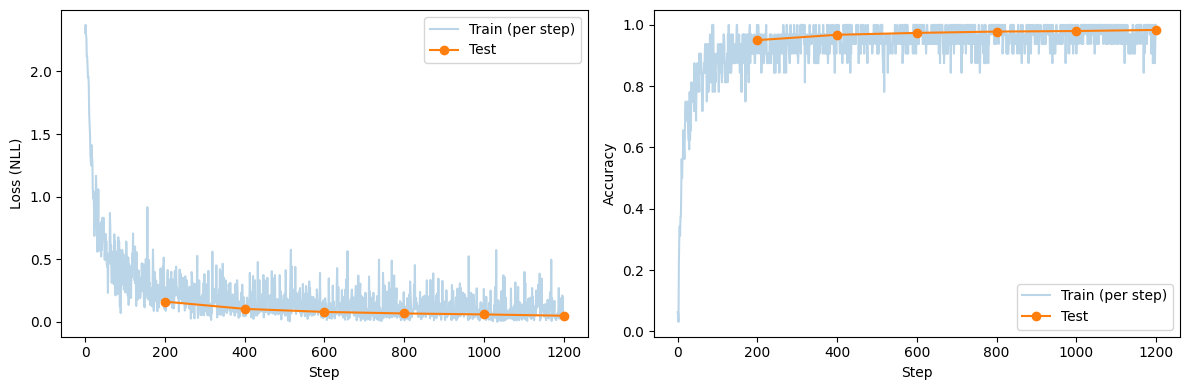

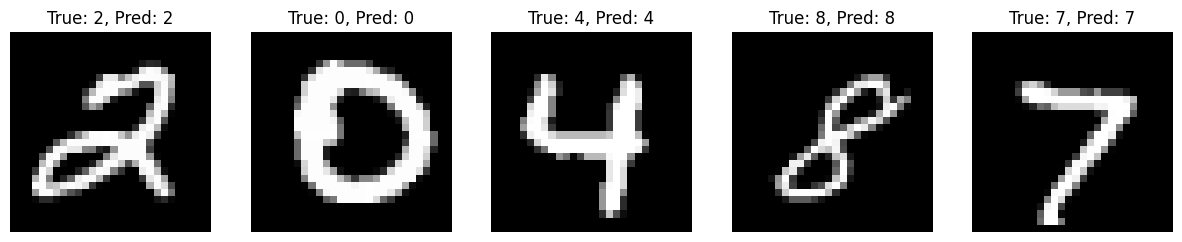

: 

In [ ]:
# Visualize Training Progress.
eval_steps = [eval_every * (i + 1) for i in range(len(history['test_acc']))]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], alpha=0.3, label='Train (per step)')
plt.plot(eval_steps, history['test_loss'], 'o-', label='Test')
plt.xlabel('Step')
plt.ylabel('Loss (NLL)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], alpha=0.3, label='Train (per step)')
plt.plot(eval_steps, history['test_acc'], 'o-', label='Test')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# Visualize Predictions.
def show_predictions(params, count=5):
  test_batch = next(iter(test_ds.as_numpy_iterator()))
  images = test_batch['image'][:count]
  labels = test_batch['label'][:count]
  logits, _ = model(params, images, is_training=False)

  dist = distrax.Categorical(logits=logits)
  preds = dist.mode()

  fig, axes = plt.subplots(1, count, figsize=(15, 3))
  for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {labels[i]}, Pred: {preds[i]}')
    ax.axis('off')
  plt.show()


show_predictions(trained_params)